In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

def mm(cc, cx, xx, fx=0.1):
    return (1-fx)**2 *cc+fx*(1-fx)*cx+fx**2 * xx

In [2]:
ma=27

kref=8.4e12 * pow(pow(10,-ma)/0.67,1/2) * 0.666**0.25

k, dcdc22, dcdc22_EdS, dcTc22, dcTc22_EdS, dcdx22, dcdx22_EdS, dcTx22, dcTx22_EdS, dxdx22, dxdx22_EdS, PL_cc, TL_x =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P22-ma{ma}p0-fx0p1-N16000-p2.txt', unpack=True)[:,:70]
k, dcdc13, dcdc13_EdS, dcTc13, dcTc13_EdS, dcdx13, dcdx13_EdS, dcTx13, dcTx13_EdS, dxdx13, dxdx13_EdS, PL_cc, TL_x, dcdx_IR  =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P13-ma{ma}p0-fx0p1-N16000-p2.txt', unpack=True)[:,:70]
fx=0.1

k, dcdc22, dcdc22_EdS, dcTc22, dcTc22_EdS, dcdx22, dcdx22_EdS, dcTx22, dcTx22_EdS, dxdx22, dxdx22_EdS, PL_cc, TL_x =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P22-ma27p0-fx0p02-N6000-p2.txt', unpack=True)[:,:70]
k, dcdc13, dcdc13_EdS, dcTc13, dcTc13_EdS, dcdx13, dcdx13_EdS, dcTx13, dcTx13_EdS, dxdx13, dxdx13_EdS, PL_cc, TL_x, dcdx_IR  =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P13-ma27p0-fx0p02-N6000-p2.txt', unpack=True)[:,:70]
fx=0.02


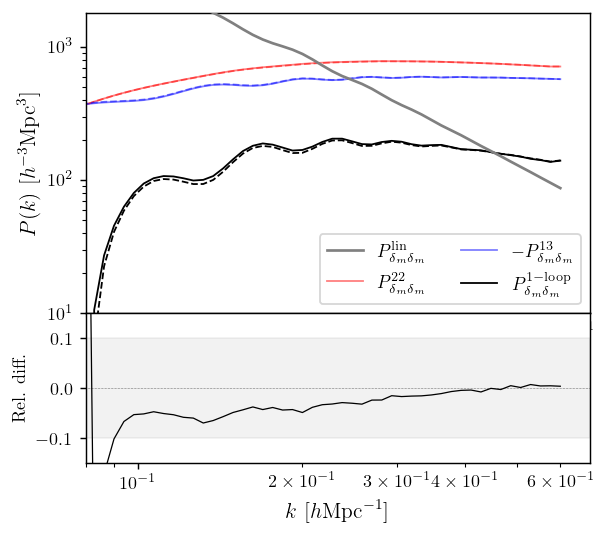

In [3]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 4.5), dpi=130, gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.0})

# Upper panel
ax1.plot(k, PL_cc*mm(1,TL_x, TL_x**2), 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', zorder=4)
ax1.plot(k, mm(dcdc22,dcdx22,dxdx22), 'r', label=r'$P^{22}_{\delta_m\delta_m}$', linewidth=1, alpha=0.5)
ax1.plot(k, mm(dcdc22_EdS,dcdx22_EdS,dxdx22_EdS) , 'r--', linewidth=1, alpha=0.5)
ax1.plot(k,-mm(dcdc13,dcdx13,dxdx13), 'b', label=r'$-P^{13}_{\delta_m\delta_m}$', linewidth=1, alpha=0.5)
ax1.plot(k, -mm(dcdc13_EdS,dcdx13_EdS,dxdx13_EdS), 'b--', linewidth=1, alpha=0.5)
ax1.plot(k, mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_m\delta_m}$', linewidth=1)
ax1.plot(k, mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS), 'k--', linewidth=1)
ax1.axhline(y=0., linestyle=':', color='k', linewidth=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_ylim([10, 1800])

ax1.legend(fontsize=10, loc='best', ncol=2)
ax1.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)
ax1.tick_params(axis='x', labelbottom=False)

# Lower panel (relative differences)
relative_diff_22 = mm(dcdc22_EdS,dcdx22_EdS,dxdx22_EdS)/ mm(dcdc22,dcdx22,dxdx22)-1
relative_diff_13 = mm(dcdc13_EdS,dcdx13_EdS,dxdx13_EdS)/ mm(dcdc13,dcdx13,dxdx13)-1
relative_diff_1l_total = mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS)/mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13)-1

relative_diff_Ptot_total = (PL_cc*mm(1,TL_x, TL_x**2)+ mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS)) / (PL_cc*mm(1,TL_x, TL_x**2)+ mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13))-1

# ax2.plot(k, relative_diff_22, 'r', label=r'Rel. diff. $P^{22}$', linewidth=1, alpha=0.5, linestyle='--')
# ax2.plot(k, relative_diff_13, 'b', label=r'Rel. diff. $P^{13}$', linewidth=1, alpha=0.5, linestyle='--')
ax2.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
# ax2.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')
ax2.axhspan(-0.1, 0.1, color='gray', alpha=0.1, zorder=0)
# ax2.axvline(x=kref, linestyle=':', color='k', linewidth=0.3)
# ax1.axvline(x=kref, linestyle=':', color='k', linewidth=0.3)

ax2.axhline(y=0., linestyle=':', color='k', linewidth=0.3)

ax2.set_ylim([-0.15,0.15])
ax2.set_xscale('log')
ax2.set_xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)
ax2.set_ylabel('Rel. diff.', fontsize=10)
# ax1.set_title(r'$m_a=10^{-'+str(ma)+r'}\,\mathrm{eV}$, $p=2$')

ax1.set_xlim([0.08, None])
ax2.set_xlim([0.08, None])

# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_num_dmdm.pdf', bbox_inches='tight')

plt.show()

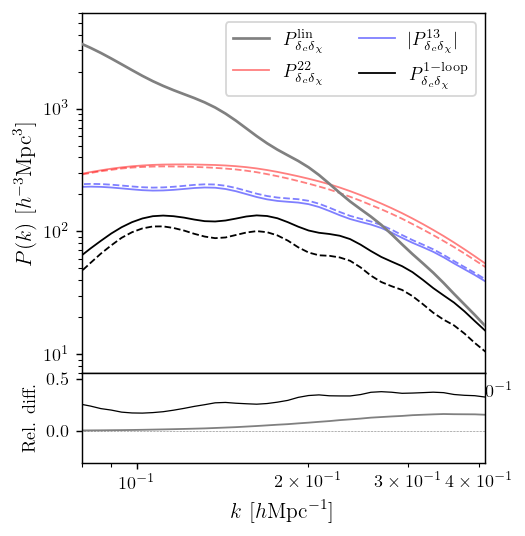

In [13]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 4.5), dpi=130, gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.0})

# Upper panel
ax1.plot(k, PL_cc*TL_x, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_\chi}$', zorder=4)
ax1.plot(k, dcdx22, 'r', label=r'$P^{22}_{\delta_c\delta_\chi}$', linewidth=1, alpha=0.5)
ax1.plot(k, dcdx22_EdS, 'r--', linewidth=1, alpha=0.5)
ax1.plot(k, -dcdx13, 'b', label=r'$|P^{13}_{\delta_c\delta_\chi}|$', linewidth=1, alpha=0.5)
ax1.plot(k, -dcdx13_EdS, 'b--', linewidth=1, alpha=0.5)
ax1.plot(k, (dcdx22+dcdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_\chi}$', linewidth=1)
ax1.plot(k, (dcdx22_EdS+dcdx13_EdS), 'k--', linewidth=1)
ax1.axhline(y=0., linestyle=':', color='k', linewidth=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_ylim([7, 6000])
# ax1.set_ylim([-300, 300])

ax1.legend(fontsize=10, loc='best', ncol=2)
ax1.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)
ax1.tick_params(axis='x', labelbottom=False)

relative_diff_1l_total = ((dcdx22 + dcdx13) - (dcdx22_EdS + dcdx13_EdS)) / (dcdx22 + dcdx13)

ax2.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = (((dcdx22 + dcdx13)) - ( dcdx22_EdS + dcdx13_EdS))/(PL_cc*TL_x + (dcdx22 + dcdx13))

ax2.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

ax2.axhline(y=0., linestyle=':', color='k', linewidth=0.3)
# ax2.axvline(x=kref, linestyle=':', color='k', linewidth=0.3)
# ax1.axvline(x=kref, linestyle=':', color='k', linewidth=0.3)

ax2.set_ylim([-0.31,0.55])
ax2.set_xscale('log')
ax2.set_xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)
ax2.set_ylabel('Rel. diff.', fontsize=10)


# ax1.set_title(r'$m_a=10^{-'+str(ma)+r'}\,\mathrm{eV}$, $p=2$')
ax1.set_xlim([0.08, 0.41])
ax2.set_xlim([0.08, 0.41])

# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_num_dcdchi.pdf', bbox_inches='tight')

plt.show()

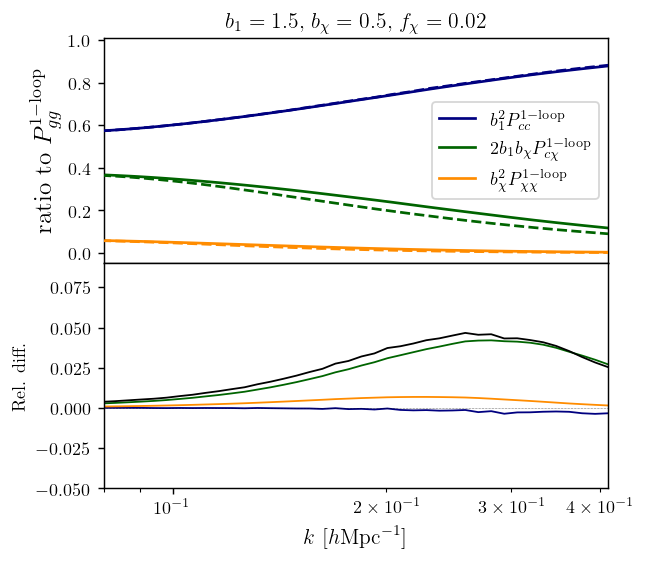

In [48]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 4.5), dpi=130, gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.0})

# Upper panel
bc = 1.5
bx = 0.5


bc2_contr = (bc**2)*(PL_cc +dcdc22 + dcdc13)
bcbx_contr = (2*bc*bx)*(TL_x*PL_cc + dcdx22 + dcdx13)
bx2_contr = (bx**2)*(TL_x**2 * PL_cc +dxdx22 + dxdx13)
Pgg = bc2_contr + bcbx_contr + bx2_contr

bc2_contr_EdS = (bc**2)*(PL_cc +dcdc22_EdS + dcdc13_EdS)
bcbx_contr_EdS = (2*bc*bx)*(TL_x*PL_cc + dcdx22_EdS + dcdx13_EdS)
bx2_contr_EdS = (bx**2)*(TL_x**2 * PL_cc +dxdx22_EdS + dxdx13_EdS)
Pgg_EdS = bc2_contr_EdS + bcbx_contr_EdS + bx2_contr_EdS

ax1.plot(k, bc2_contr/Pgg, 'navy',linewidth=1.5, label=r'$b_1^2 P_{cc}^{\mathrm{1-loop}}$')
ax1.plot(k, bc2_contr_EdS/Pgg, 'navy',linestyle='--', linewidth=1.5, zorder=4)


ax1.plot(k, bcbx_contr/Pgg, 'darkgreen',linewidth=1.5, label=r'$2b_1b_\chi P_{c\chi}^{\mathrm{1-loop}}$')
ax1.plot(k, bcbx_contr_EdS/Pgg, 'darkgreen',linestyle='--', linewidth=1.5, zorder=4)

ax1.plot(k, bx2_contr/Pgg, 'darkorange',linewidth=1.5,label=r'$b_\chi^2 P_{\chi\chi}^{\mathrm{1-loop}}$')
ax1.plot(k, bx2_contr_EdS/Pgg, 'darkorange', linestyle='--', linewidth=1.5, zorder=4)


ax1.legend(fontsize=10, loc='best')
ax1.set_ylabel(r'ratio to $P_{gg}^{\mathrm{1-loop}}$', fontsize=14)
ax1.set_title(r'$b_1=1.5,\,b_\chi=0.5, \, f_\chi =0.02$', fontsize=12)
ax1.tick_params(axis='x', labelbottom=False)

ax2.plot(k, (bc2_contr-bc2_contr_EdS)/Pgg, 'navy', linewidth=1., linestyle='-')

ax2.plot(k, (bcbx_contr-bcbx_contr_EdS)/Pgg, 'darkgreen', linewidth=1., linestyle='-')
ax2.plot(k, (bx2_contr-bx2_contr_EdS)/Pgg, 'darkorange', linewidth=1., linestyle='-')

ax2.plot(k, (Pgg-Pgg_EdS)/Pgg, 'k', linewidth=1., linestyle='-')


ax2.axhline(y=0., linestyle=':', color='k', linewidth=0.3)
# ax2.axvline(x=kref, linestyle=':', color='k', linewidth=0.3)
# ax1.axvline(x=kref, linestyle=':', color='k', linewidth=0.3)

ax2.set_ylim([-0.05,0.09])
ax2.set_xscale('log')
ax2.set_xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)
ax2.set_ylabel('Rel. diff.', fontsize=10)


# ax1.set_title(r'$m_a=10^{-'+str(ma)+r'}\,\mathrm{eV}$, $p=2$')
ax1.set_xlim([0.08, 0.41])
ax2.set_xlim([0.08, 0.41])

# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_num_dcdchi.pdf', bbox_inches='tight')

plt.show()

Fitted value for c_cchi: -6.9884739987331495 and c_cc: 0.2589461484084107


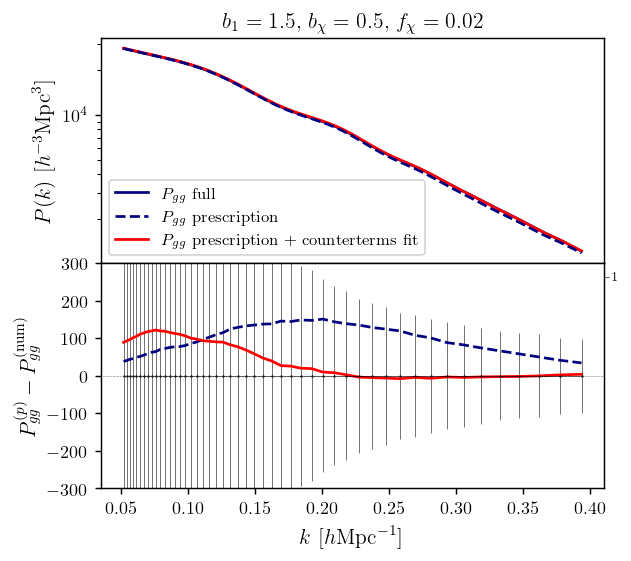

In [6]:
from scipy.optimize import curve_fit

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 4.5), dpi=130, gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.0})

# Upper panel
bc = 1.5
bx = 0.5


bc2_contr = (bc**2)*(PL_cc +dcdc22 + dcdc13)
bcbx_contr = (2*bc*bx)*(TL_x*PL_cc + dcdx22 + dcdx13)
bx2_contr = (bx**2)*(TL_x**2 * PL_cc +dxdx22 + dxdx13)
Pgg = bc2_contr + bcbx_contr + bx2_contr

bc2_contr_EdS = (bc**2)*(PL_cc +dcdc22_EdS + dcdc13_EdS)
bcbx_contr_EdS = (2*bc*bx)*(TL_x*PL_cc + dcdx22_EdS + dcdx13_EdS)
bx2_contr_EdS = (bx**2)*(TL_x**2 * PL_cc +dxdx22_EdS + dxdx13_EdS)
Pgg_EdS = bc2_contr_EdS + bcbx_contr_EdS + bx2_contr_EdS

kmask = (k<0.4) & (k>0.05)

ax1.plot(k[kmask], Pgg[kmask], 'navy',linewidth=1.5, label=r'$P_{gg}$ full ')
ax1.plot(k[kmask], Pgg_EdS[kmask], 'navy',linestyle='--', linewidth=1.5, zorder=4, label=r'$P_{gg}$ prescription ')


def func(k, ccx, cxx):
    return (Pgg_EdS[kmask] - ccx * k[kmask]**2 *TL_x[kmask]* PL_cc[kmask]- cxx * k[kmask]**2  *TL_x[kmask]**2 * PL_cc[kmask])

def func(k, ccx, ccc):
    return (Pgg_EdS[kmask] - ccx * k[kmask]**2 *TL_x[kmask]* PL_cc[kmask]- ccc * k[kmask]**2 * PL_cc[kmask])


# ERRORBARS PART
Cfull = np.loadtxt('/home/fverdian/class/soundspeed-scripts/numerical-integrals/cutofftests/C_024Q_ngc_z3.txt')
kboss, _, _, _ =  np.loadtxt('/home/fverdian/class/soundspeed-scripts/numerical-integrals/cutofftests/pk_boss_ngc_z3_fkp.txt', unpack=True)
CQ0Q0 = np.diag(Cfull[-78:,-78:])
CQ0_k = interp1d(kboss, CQ0Q0, kind='linear')(k[kmask])

# Fit the curve
popt, pcov = curve_fit(func, k, Pgg[kmask], sigma=CQ0_k)

# Extract the fitted c value
ccx_fitted = popt[0]
cxx_fitted = popt[1]

# Print the fitted c value
print(f"Fitted value for c_cchi: {ccx_fitted} and c_cc: {cxx_fitted}")

# Plot the fitted curve
ax1.plot(k[kmask], func(k, ccx_fitted,cxx_fitted), 'red', linestyle='-', linewidth=1.5, label=r'$P_{gg}$ prescription + counterterms fit')

ax1.legend(fontsize=9, loc='best')

ax1.set_title(r'$b_1=1.5,\,b_\chi=0.5, \, f_\chi =0.02$', fontsize=12)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)

reldifforig = (Pgg-Pgg_EdS)
reldifffitted = (func(k, ccx_fitted,cxx_fitted) - Pgg[kmask])


ax2.errorbar(k[kmask], np.zeros_like(CQ0_k), yerr = np.sqrt(CQ0_k), color='k', linewidth=0.3, marker='o', markersize=0.3, label=r'Fitted curve')


ax2.plot(k[kmask], reldifforig[kmask], 'navy', linestyle='--', linewidth=1.5, label=r'Fitted curve')
ax2.plot(k[kmask], reldifffitted, 'r', linestyle='-', linewidth=1.5, label=r'Fitted curve')
ax2.axhline(y=0., linestyle=':', color='k', linewidth=0.3)

ax2.set_ylim([-300,300])
ax2.set_xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)
ax2.set_ylabel(r'$P_{gg}^{(p)}-P_{gg}^{(\mathrm{num})}$', fontsize=12)

# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_num_dcdchi.pdf', bbox_inches='tight')

plt.show()

In [7]:
h=0.67
print(np.sqrt(5/9)* 5.e-2 * (1./0.1) * pow(0.666,1/2)* np.sqrt(0.142/h/h/0.3))
print(8.4e12 * pow(1.e-27/h,1/2) * 0.666**0.25)

0.3123054826404192
0.29316386723709065


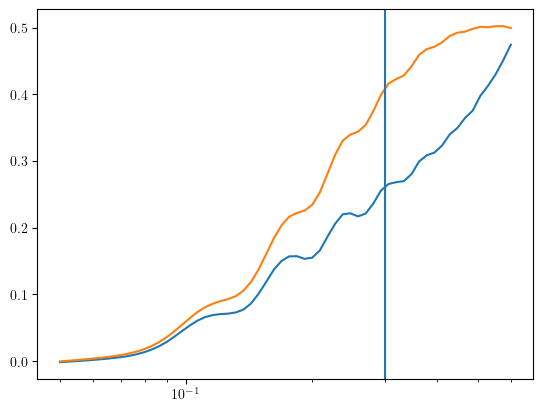

In [5]:
ol_over_linear_cross = (dcdx22_EdS + dcdx13_EdS)/(PL_cc*TL_x+dcdx22 + dcdx13)
ol_over_linear_cross_ex = (dcdx22 + dcdx13)/(PL_cc*TL_x+dcdx22 + dcdx13)

# ol_over_linear_auto = (dcdc22_EdS + dcdc13_EdS)/(PL_cc+dcdc22_EdS + dcdc13_EdS)

# plt.semilogx(k,ol_over_linear_cross)
plt.semilogx(k,ol_over_linear_cross)
plt.semilogx(k,ol_over_linear_cross_ex)

plt.axvline(0.3)
# plt.plot(k,(PL_cc+ (dcdc22_EdS + dcdc13_EdS)))

plt.show()


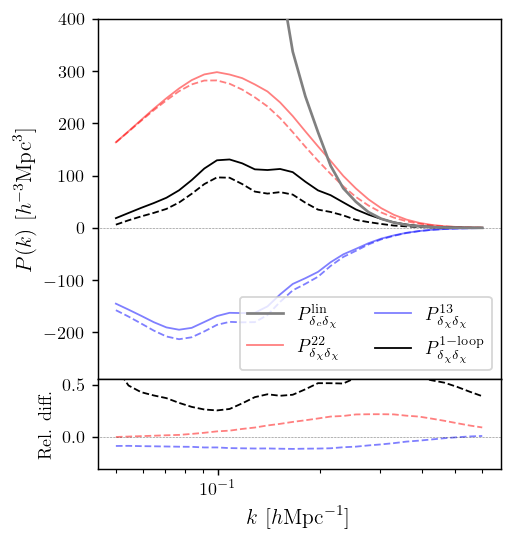

In [17]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 4.5), dpi=130, gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.0})

# Upper panel
ax1.plot(k, PL_cc*TL_x*TL_x, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_\chi}$', zorder=4)
ax1.plot(k, dxdx22, 'r', label=r'$P^{22}_{\delta_\chi\delta_\chi}$', linewidth=1, alpha=0.5)
ax1.plot(k, dxdx22_EdS, 'r--', linewidth=1, alpha=0.5)
ax1.plot(k, dxdx13, 'b', label=r'$P^{13}_{\delta_\chi\delta_\chi}$', linewidth=1, alpha=0.5)
ax1.plot(k, dxdx13_EdS, 'b--', linewidth=1, alpha=0.5)
ax1.plot(k, (dxdx22+dxdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_\chi\delta_\chi}$', linewidth=1)
ax1.plot(k, (dxdx22_EdS+dxdx13_EdS), 'k--', linewidth=1)
ax1.axhline(y=0., linestyle=':', color='k', linewidth=0.3)
ax1.set_xscale('log')
# ax1.set_yscale('log')

ax1.set_ylim([-290, 400])

ax1.legend(fontsize=10, loc='best', ncol=2)
ax1.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)
ax1.tick_params(axis='x', labelbottom=False)

# Lower panel (relative differences)
relative_diff_22 = (dxdx22 - dxdx22_EdS) / dxdx22
relative_diff_13 = (dxdx13 - dxdx13_EdS) / dxdx13
relative_diff_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (dxdx22 + dxdx13)

ax2.plot(k, relative_diff_22, 'r', label=r'Rel. diff. $P^{22}$', linewidth=1, alpha=0.5, linestyle='--')
ax2.plot(k, relative_diff_13, 'b', label=r'Rel. diff. $P^{13}$', linewidth=1, alpha=0.5, linestyle='--')
ax2.plot(k, relative_diff_total, 'k', linewidth=1, linestyle='--')
ax2.axhline(y=0., linestyle=':', color='k', linewidth=0.3)

ax2.set_ylim([-0.31,0.55])
ax2.set_xscale('log')
ax2.set_xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)
ax2.set_ylabel('Rel. diff.', fontsize=10)
# ax1.set_xlim([0.08, None])
# ax2.set_xlim([0.08, None])

# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_num_dcdchi.pdf', bbox_inches='tight')

plt.show()

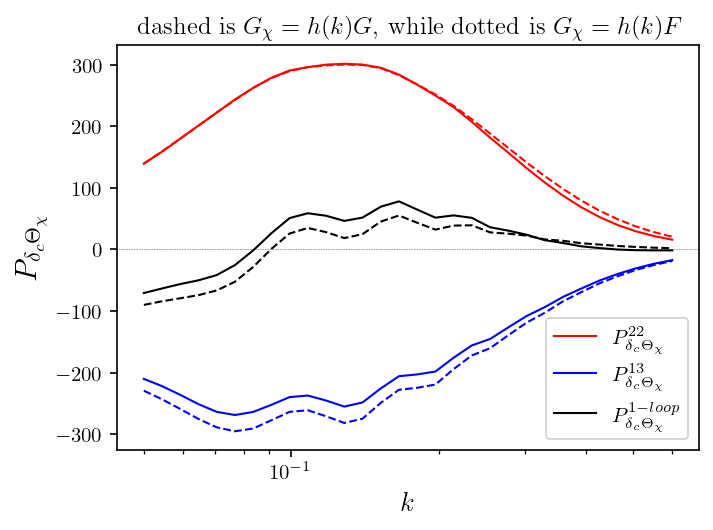

In [4]:
plt.figure(figsize=(5,3.5),dpi=150)


plt.plot(k, dcTx22, 'r', label=r'$P^{22}_{\delta_c\Theta_\chi}$', linewidth=1)
plt.plot(k, dcTx22_EdS, 'r--', linewidth=1)


plt.plot(k, dcTx13, 'b', label=r'$P^{13}_{\delta_c\Theta_\chi}$', linewidth=1)
plt.plot(k, dcTx13_EdS, 'b--', linewidth=1)

plt.plot(k, dcTx22+dcTx13, 'k', label=r'$P^{1-loop}_{\delta_c\Theta_\chi}$', linewidth=1)
plt.plot(k, dcTx22_EdS+dcTx13_EdS, 'k--',linewidth=1)

plt.axhline(y=0.,linestyle=':', color='k', linewidth=0.3)

plt.xscale('log')
plt.ylabel(r"$P_{\delta_c\Theta_\chi}$", fontsize=15)
plt.legend(fontsize=10, loc='best')
plt.xlabel(r'$k$', fontsize=13)
plt.title('dashed is $G_\chi=h(k) G$, while dotted is $G_\chi=h(k) F$')
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/P-1loop-theory-deltaTheta.pdf', bbox_inches='tight')
plt.show()


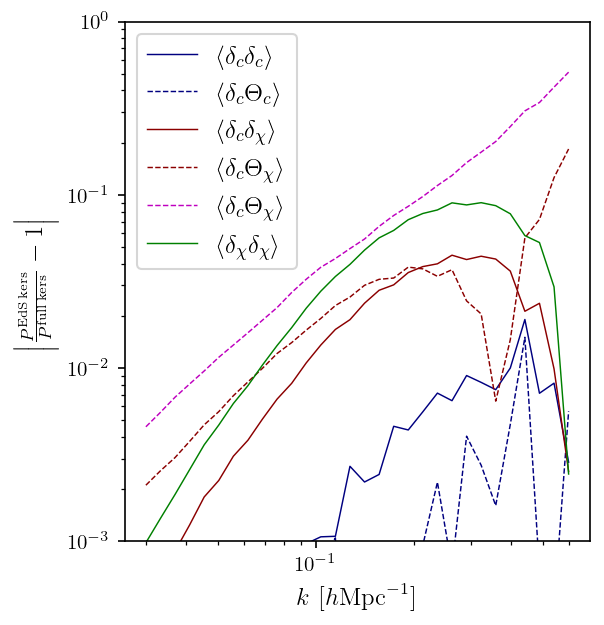

In [6]:
plt.figure(figsize=(4,4.5),dpi=150)

plt.plot(k, np.abs((PL_cc+dcdc22_EdS+dcdc13_EdS)/(PL_cc+dcdc22+dcdc13)-1), 'navy', label=r'$\left<\delta_c\delta_c\right>$', linewidth=0.7)
plt.plot(k, np.abs((PL_cc+dcTc22_EdS+dcTc13_EdS)/(PL_cc+dcTc22+dcTc13)-1), 'navy', linestyle='--', label=r'$\left<\delta_c\Theta_c\right>$', linewidth=0.7)

plt.plot(k, np.abs((PL_cc*TL_x+dcdx22_EdS+dcdx13_EdS)/(PL_cc*TL_x+dcdx22+dcdx13)-1), 'darkred', label=r'$\left<\delta_c\delta_\chi\right>$', linewidth=0.7)
plt.plot(k, np.abs((PL_cc*TL_x+dcTx22_EdS+dcTx13_EdS)/(PL_cc*TL_x+dcTx22+dcTx13)-1), 'darkred', linestyle='--', label=r'$\left<\delta_c\Theta_\chi\right>$', linewidth=0.7)

plt.plot(k, np.abs((PL_cc*TL_x+dcTx22_EdS_old+dcTx13_EdS_old)/(PL_cc*TL_x+dcTx22+dcTx13)-1), 'm', linestyle='--', label=r'$\left<\delta_c\Theta_\chi\right>$', linewidth=0.7)

plt.plot(k, np.abs((PL_cc*TL_x*TL_x+dxdx22_EdS+dxdx13_EdS)/(PL_cc*TL_x*TL_x+dxdx22+dxdx13)-1), 'g', label=r'$\left<\delta_\chi\delta_\chi\right>$', linewidth=0.7)

plt.xscale('log')
plt.yscale('log')
plt.ylim([1.e-3,1])

plt.legend(fontsize=12, loc='upper left')
plt.xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)
plt.ylabel(r"$\Big|\frac{P^{\mathrm{EdS\,kers}}}{P^\mathrm{full\,kers}}-1\Big|$", fontsize=12)

# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_num_ratio.pdf', bbox_inches='tight')

plt.show()

----
Plot the difference for $m_a= 10^{-26}$: it scales as a counterterm

In [25]:
ma=27
k, dcdc22, dcdc22_EdS, dcTc22, dcTc22_EdS, dcdx22, dcdx22_EdS, dcTx22, dcTx22_EdS, dxdx22, dxdx22_EdS, PL_cc, TL_x =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P22-ma{ma}p0-fx0p1-N1000-p2.txt', unpack=True)[:,:70]

k, dcdc13, dcdc13_EdS, dcTc13, dcTc13_EdS, dcdx13, dcdx13_EdS, dcTx13, dcTx13_EdS, dxdx13, dxdx13_EdS, PL_cc, TL_x, dcdx_IR  =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P13-ma{ma}p0-fx0p1-N1000-p2.txt', unpack=True)[:,:70]


/tmp/ipykernel_3572011/3487093292.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b:" (-> linestyle=':'). The keyword argument will take precedence.
  ax2.plot(k, diff_1l_total[-18]*(k/k[-18])**2, 'b:', linewidth=1, linestyle='-', label=r'$k^2$ slope')


0.9270655481324206


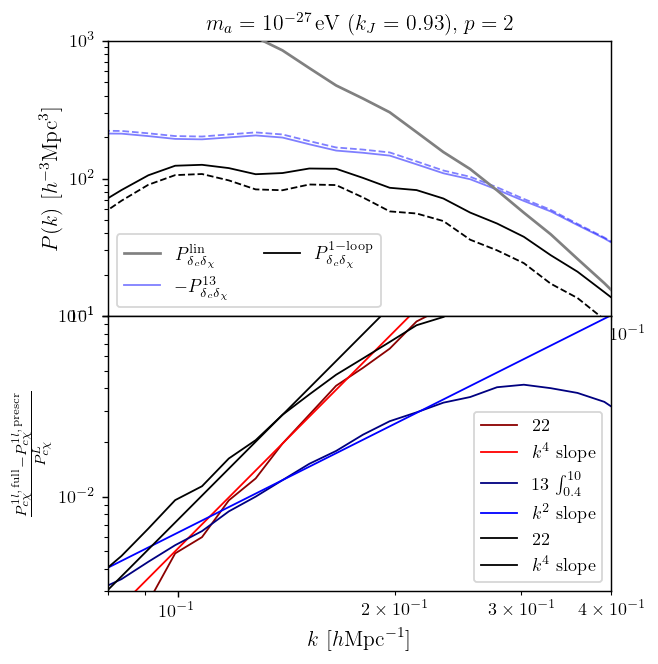

In [27]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5,5.5), dpi=130, gridspec_kw={'height_ratios': [4, 4], 'hspace': 0.0})

# Upper panel
ax1.plot(k, PL_cc*TL_x, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_\chi}$', zorder=4)
# ax1.plot(k, dcdx22, 'r', label=r'$P^{22}_{\delta_c\delta_\chi}$', linewidth=1, alpha=0.5)
# ax1.plot(k, dcdx22_EdS, 'r--', linewidth=1, alpha=0.5)
ax1.plot(k, -dcdx13, 'b', label=r'$-P^{13}_{\delta_c\delta_\chi}$', linewidth=1, alpha=0.5)
ax1.plot(k, -dcdx13_EdS, 'b--', linewidth=1, alpha=0.5)
ax1.plot(k, (dcdx22+dcdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_\chi}$', linewidth=1)
ax1.plot(k, (dcdx22_EdS+dcdx13_EdS), 'k--', linewidth=1)
ax1.axhline(y=0., linestyle=':', color='k', linewidth=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_ylim([10, 1000])

ax1.legend(fontsize=10, loc='best', ncol=2)
ax1.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)
ax1.tick_params(axis='x', labelbottom=False)

# Lower panel (relative differences)
diff_1l_total = np.abs((dcdx22) - (dcdx22_EdS))/(PL_cc*TL_x)
ax2.plot(k, diff_1l_total, 'darkred', linewidth=1, linestyle='-', label=r'22')
ax2.plot(k, diff_1l_total[-18]*(k/k[-18])**4, 'r', linewidth=1, linestyle='-', label=r'$k^4$ slope')

diff_1l_total = np.abs((dcdx13) - (dcdx13_EdS))/(PL_cc*TL_x)
ax2.plot(k, diff_1l_total, 'navy', linewidth=1, linestyle='-', label=r'13 $\int_{0.4}^{10}$')
ax2.plot(k, diff_1l_total[-18]*(k/k[-18])**2, 'b:', linewidth=1, linestyle='-', label=r'$k^2$ slope')

diff_1l_total = np.abs((dcdx22+dcdx13) - (dcdx22_EdS+dcdx13_EdS))/(PL_cc*TL_x+dcdx22+dcdx13)
ax2.plot(k, diff_1l_total, 'k', linewidth=1, linestyle='-', label=r'22')
ax2.plot(k, diff_1l_total[-18]*(k/k[-18])**4, 'k', linewidth=1, linestyle='-', label=r'$k^4$ slope')
# ax2.axvline(k[-18])
ax2.set_yscale('log')

ax2.axhline(y=0., linestyle=':', color='k', linewidth=0.3)
ax2.set_ylim([3.e-3,0.1])
ax2.set_xscale('log')
ax2.set_xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)
ax2.set_ylabel(r'$\frac{P_{c\chi}^{1l,\,\mathrm{full}}-P_{c\chi}^{1l,\,\mathrm{prescr}}}{P_{c\chi}^{L}}$', fontsize=12)
ax2.legend(fontsize=10, loc='best', ncol=1)


ax1.set_title(r'$m_a=10^{-'+str(ma)+r'}\,\mathrm{eV}$ ($k_J=0.93$), $p=2$')
ax1.set_xlim([0.08, 0.4])
ax2.set_xlim([0.08, 0.4])

# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_num_dcdchi.pdf', bbox_inches='tight')
print(8.4e12 * pow(pow(10,-26)/0.67,1/2) * 0.666**0.25)
plt.show()